# 03 — PM2.5 Prediction: Regression Models
**Gurugram Air Quality Study (2020–2024)**

| Model | Features | Type |
|---|---|---|
| Linear Regression | 3 basic meteo vars (RH, WS, month) | Minimal Baseline |
| Ridge Regression | 6 meteo vars + season | Regularized Baseline |
| Random Forest | Full (meteo + satellite + lag) | Ensemble |
| XGBoost | Full (meteo + satellite + lag) | Gradient Boosting |

**Requires:** Run `01_data_preprocessing.ipynb` first.

## 1. Imports & Load Data

In [1]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 300, 'font.size': 11})

BASE = os.getcwd()
OUT  = os.path.join(BASE, 'outputs')
os.makedirs(OUT, exist_ok=True)

df = pd.read_csv(os.path.join(OUT, 'merged_clean.csv'), parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
print(f'Loaded: {df.shape}')
df.head(3)

Loaded: (1768, 32)


,date,PM2.5 (µg/m³),PM10 (µg/m³),NO (µg/m³),NO2 (µg/m³),NOx (ppb),NH3 (µg/m³),SO2 (µg/m³),CO (mg/m³),Ozone (µg/m³),...,O3,month,day_of_year,year,season,season_enc,PM2.5_lag1,PM2.5_lag7,AQI_category,AQI_label
0,2020-01-01,305.93,NaN,201.53,53.10,203.70,NaN,17.60,3.98,24.78,...,0.160842,1,1,2020,Winter,0,NaN,NaN,Severe,4.0
1,2020-01-02,71.69,NaN,67.04,52.42,78.21,NaN,8.70,2.01,47.42,...,0.161014,1,2,2020,Winter,0,305.93,NaN,Poor,2.0
2,2020-01-03,25.41,NaN,23.90,38.65,37.23,NaN,3.36,1.17,69.87,...,0.142446,1,3,2020,Winter,0,71.69,NaN,Good,0.0


## 2. Feature Selection & Preprocessing

- **Linear features (3)**: RH, WS, month — the minimal possible meteorological baseline.
- **Ridge features (6)**: adds WD, SR, season_enc — full meteo set, L2-regularized.
- **Full features (19)**: adds Sentinel-5P satellite gases + LST + lag — used by RF and XGBoost.

> `AT (°C)` and `PM10` are excluded — both are >99% NaN in this dataset.

In [2]:
TARGET = 'PM2.5 (µg/m³)'

# Minimal baseline: 3 basic meteo vars — intentionally simplest possible
LINEAR_CANDIDATES = ['RH (%)', 'WS (m/s)', 'month']
LINEAR_FEATURES = [f for f in LINEAR_CANDIDATES if f in df.columns]
print(f'Linear features ({len(LINEAR_FEATURES)}): {LINEAR_FEATURES}')

# Ridge baseline: full meteo set, no satellite, no lag
BASELINE_CANDIDATES = [
    'RH (%)', 'WS (m/s)', 'WD (deg)', 'SR (W/mt2)', 'month', 'season_enc'
]
BASELINE_FEATURES = [f for f in BASELINE_CANDIDATES if f in df.columns]
print(f'Ridge/Baseline features ({len(BASELINE_FEATURES)}): {BASELINE_FEATURES}')

# Full: meteo + satellite + lag
FULL_CANDIDATES = [
    'RH (%)', 'WS (m/s)', 'WD (deg)', 'SR (W/mt2)', 'BP (mmHg)',
    'LST_C', 'AAI', 'CO', 'HCHO', 'NO2', 'O3',
    'NO2 (µg/m³)', 'CO (mg/m³)', 'Ozone (µg/m³)',
    'month', 'season_enc', 'day_of_year',
    'PM2.5_lag1', 'PM2.5_lag7',
]
FULL_FEATURES = [f for f in FULL_CANDIDATES if f in df.columns]
print(f'Full features ({len(FULL_FEATURES)}): {FULL_FEATURES}')

all_cols = list(set(LINEAR_FEATURES + BASELINE_FEATURES + FULL_FEATURES))
data = df[[TARGET] + all_cols].dropna(subset=[TARGET])
print(f'Rows with PM2.5 target: {len(data)}')

Linear features (3): ['RH (%)', 'WS (m/s)', 'month']
Ridge/Baseline features (6): ['RH (%)', 'WS (m/s)', 'WD (deg)', 'SR (W/mt2)', 'month', 'season_enc']
Full features (19): ['RH (%)', 'WS (m/s)', 'WD (deg)', 'SR (W/mt2)', 'BP (mmHg)', 'LST_C', 'AAI', 'CO', 'HCHO', 'NO2', 'O3', 'NO2 (µg/m³)', 'CO (mg/m³)', 'Ozone (µg/m³)', 'month', 'season_enc', 'day_of_year', 'PM2.5_lag1', 'PM2.5_lag7']
Rows with PM2.5 target: 1768


## 3. Train / Test Split & Imputation

In [3]:
from sklearn.model_selection import train_test_split

# Random 80/20 split — standard for ML model evaluation in research papers.
X_all_linear = data[LINEAR_FEATURES].values
X_all_base   = data[BASELINE_FEATURES].values
y_all        = data[TARGET].values
X_all_full   = data[FULL_FEATURES].values

def make_X(X_tr_raw, X_te_raw, feature_list):
    """Impute (median) then scale. Returns scaled, raw, surviving feature names."""
    imp = SimpleImputer(strategy='median')
    imp.fit(X_tr_raw)
    used   = [f for f, k in zip(feature_list, ~np.isnan(imp.statistics_)) if k]
    Xtr    = imp.transform(X_tr_raw)
    Xte    = imp.transform(X_te_raw)
    sc     = StandardScaler()
    return sc.fit_transform(Xtr), sc.transform(Xte), Xtr, Xte, used

# Same random split for all feature sets so test rows match
idx = np.arange(len(data))
idx_train, idx_test = train_test_split(idx, test_size=0.20, random_state=42)
idx_train, idx_test = sorted(idx_train), sorted(idx_test)

y_train = y_all[idx_train]
y_test  = y_all[idx_test]
split_idx = idx_test[0]

Xtr_lin_sc,  Xte_lin_sc,  Xtr_lin,  Xte_lin,  LIN_USED  = make_X(
    X_all_linear[idx_train], X_all_linear[idx_test], LINEAR_FEATURES)
Xtr_base_sc, Xte_base_sc, Xtr_base, Xte_base, BASE_USED = make_X(
    X_all_base[idx_train], X_all_base[idx_test], BASELINE_FEATURES)
Xtr_full_sc, Xte_full_sc, Xtr_full, Xte_full, FULL_USED = make_X(
    X_all_full[idx_train], X_all_full[idx_test], FULL_FEATURES)

print(f'Linear X_train:   {Xtr_lin.shape}   features: {LIN_USED}')
print(f'Baseline X_train: {Xtr_base.shape}  features: {BASE_USED}')
print(f'Full     X_train: {Xtr_full.shape}')
print(f'Full features used ({len(FULL_USED)}): {FULL_USED}')
print(f'Train rows: {len(y_train)} | Test rows: {len(y_test)}')

Linear X_train:   (1414, 3)   features: ['RH (%)', 'WS (m/s)', 'month']
Baseline X_train: (1414, 6)  features: ['RH (%)', 'WS (m/s)', 'WD (deg)', 'SR (W/mt2)', 'month', 'season_enc']
Full     X_train: (1414, 19)
Full features used (19): ['RH (%)', 'WS (m/s)', 'WD (deg)', 'SR (W/mt2)', 'BP (mmHg)', 'LST_C', 'AAI', 'CO', 'HCHO', 'NO2', 'O3', 'NO2 (µg/m³)', 'CO (mg/m³)', 'Ozone (µg/m³)', 'month', 'season_enc', 'day_of_year', 'PM2.5_lag1', 'PM2.5_lag7']
Train rows: 1414 | Test rows: 354


## 4. Train All Models

In [4]:
def evaluate(name, feat_set, y_true, y_pred, elapsed):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'{name:<32}  MAE={mae:6.2f}  RMSE={rmse:6.2f}  R2={r2:5.3f}  ({elapsed:.1f}s)')
    return {'Model': name, 'Feature Set': feat_set,
            'MAE': round(mae, 2), 'RMSE': round(rmse, 2),
            'R2': round(r2, 3), 'Time(s)': round(elapsed, 1)}

results     = []
predictions = {}

# Linear Regression — minimal baseline (3 meteo vars: RH, WS, month)
t0 = time.time()
lr = LinearRegression()
lr.fit(Xtr_lin_sc, y_train)
y_pred_lr = lr.predict(Xte_lin_sc)
results.append(evaluate('Linear Regression (baseline)', 'Meteo (3 vars)', y_test, y_pred_lr, time.time()-t0))
predictions['Linear Regression'] = y_pred_lr

# Ridge Regression — regularized baseline (6 meteo vars)
t0 = time.time()
ridge = Ridge(alpha=1.0)
ridge.fit(Xtr_base_sc, y_train)
y_pred_ridge = ridge.predict(Xte_base_sc)
results.append(evaluate('Ridge Regression (baseline)', 'Meteo (6 vars)', y_test, y_pred_ridge, time.time()-t0))
predictions['Ridge Regression'] = y_pred_ridge

# Random Forest — full features
t0 = time.time()
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(Xtr_full, y_train)
y_pred_rf = rf.predict(Xte_full)
results.append(evaluate('Random Forest', 'Full (19 vars)', y_test, y_pred_rf, time.time()-t0))
predictions['Random Forest'] = y_pred_rf

# XGBoost — full features
t0 = time.time()
xgb_model = xgb.XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=0
)
xgb_model.fit(Xtr_full, y_train)
y_pred_xgb = xgb_model.predict(Xte_full)
results.append(evaluate('XGBoost', 'Full (19 vars)', y_test, y_pred_xgb, time.time()-t0))
predictions['XGBoost'] = y_pred_xgb

Linear Regression (baseline)      MAE= 43.88  RMSE= 58.71  R2=0.019  (0.0s)
Ridge Regression (baseline)       MAE= 38.65  RMSE= 53.05  R2=0.199  (0.0s)
Random Forest                     MAE= 23.84  RMSE= 38.02  R2=0.589  (0.5s)
XGBoost                           MAE= 23.47  RMSE= 35.88  R2=0.634  (1.0s)


In [5]:
results_df = pd.DataFrame(results)

print('=' * 72)
print('           PM2.5 REGRESSION MODEL COMPARISON TABLE')
print('=' * 72)
print(results_df.to_string(index=False))
print('=' * 72)
print('Lower MAE/RMSE = better  |  Higher R2 = better  |  Max R2 = 1.0')

results_df.to_csv(os.path.join(OUT, 'regression_comparison.csv'), index=False)
print('Saved -> outputs/regression_comparison.csv')
results_df

           PM2.5 REGRESSION MODEL COMPARISON TABLE
                       Model    Feature Set   MAE  RMSE    R2  Time(s)
Linear Regression (baseline) Meteo (3 vars) 43.88 58.71 0.019      0.0
 Ridge Regression (baseline) Meteo (6 vars) 38.65 53.05 0.199      0.0
               Random Forest Full (19 vars) 23.84 38.02 0.589      0.5
                     XGBoost Full (19 vars) 23.47 35.88 0.634      1.0
Lower MAE/RMSE = better  |  Higher R2 = better  |  Max R2 = 1.0
Saved -> outputs/regression_comparison.csv


,Model,Feature Set,MAE,RMSE,R2,Time(s)
0,Linear Regression (baseline),Meteo (3 vars),43.88,58.71,0.019,0.0
1,Ridge Regression (baseline),Meteo (6 vars),38.65,53.05,0.199,0.0
2,Random Forest,Full (19 vars),23.84,38.02,0.589,0.5
3,XGBoost,Full (19 vars),23.47,35.88,0.634,1.0


## 6. Comparison Bar Chart

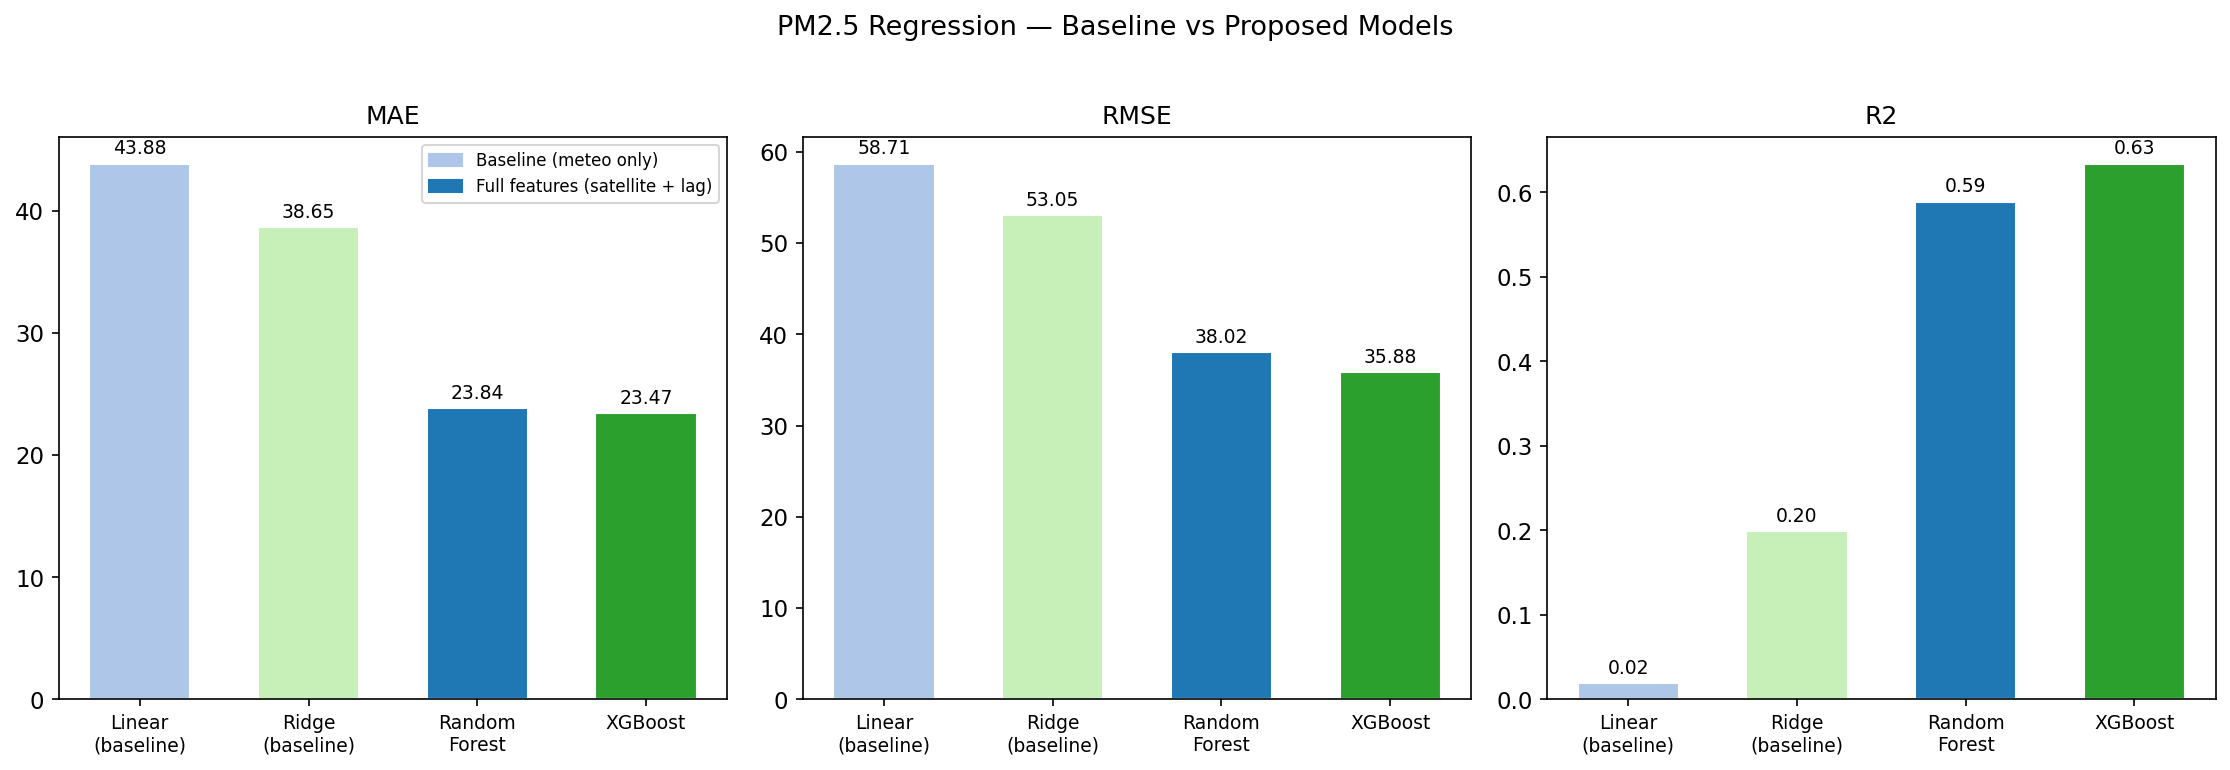

In [6]:
from matplotlib.patches import Patch

bar_colors  = ['#aec7e8', '#c7efb8', '#1f77b4', '#2ca02c']
short_names = ['Linear\n(baseline)', 'Ridge\n(baseline)', 'Random\nForest', 'XGBoost']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    vals = results_df[metric].values
    bars = ax.bar(range(len(vals)), vals, color=bar_colors, edgecolor='white', width=0.6)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(short_names, fontsize=9)
    ax.set_title(metric, fontsize=12)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

axes[0].legend(handles=[
    Patch(color='#aec7e8', label='Baseline (meteo only)'),
    Patch(color='#1f77b4', label='Full features (satellite + lag)'),
], fontsize=8)

fig.suptitle('PM2.5 Regression — Baseline vs Proposed Models', fontsize=13, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'regression_comparison_bar.png'), bbox_inches='tight')
plt.show()

## 7. Feature Importance — Random Forest

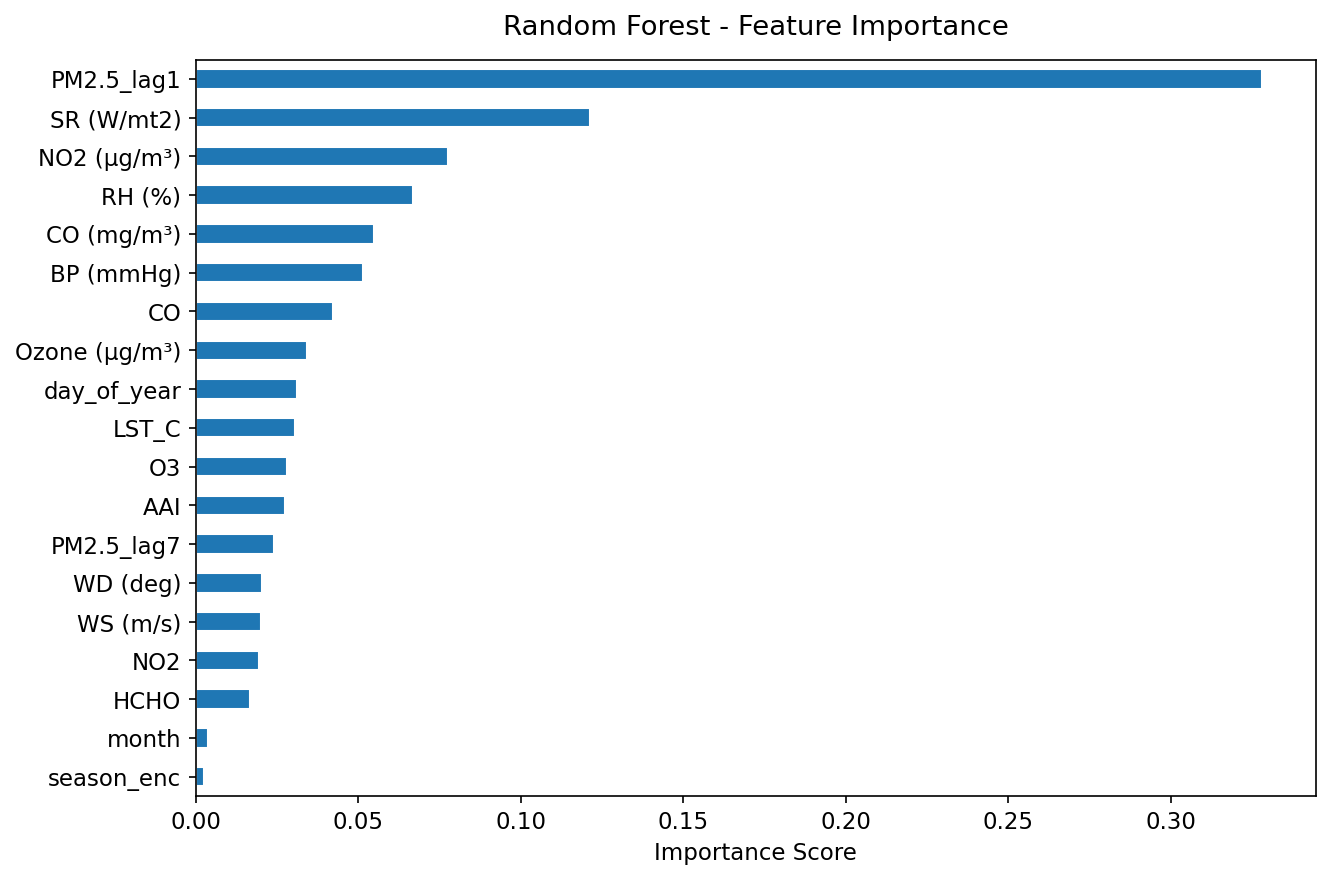

PM2.5_lag1       0.328214
SR (W/mt2)       0.121256
NO2 (µg/m³)      0.077645
RH (%)           0.066696
CO (mg/m³)       0.054841
BP (mmHg)        0.051361
CO               0.042139
Ozone (µg/m³)    0.034055
day_of_year      0.031177
LST_C            0.030570
O3               0.027920
AAI              0.027500
PM2.5_lag7       0.024133
WD (deg)         0.020208
WS (m/s)         0.019996
NO2              0.019426
HCHO             0.016696
month            0.003753
season_enc       0.002413
dtype: float64

In [7]:
assert len(rf.feature_importances_) == len(FULL_USED), \
    f'Mismatch: {len(rf.feature_importances_)} importances vs {len(FULL_USED)} names'

fi_rf = pd.Series(rf.feature_importances_, index=FULL_USED).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
fi_rf.plot.barh(ax=ax, color='#1f77b4', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Random Forest - Feature Importance', pad=12)
ax.set_xlabel('Importance Score')
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'feature_importance_rf.png'))
plt.show()
fi_rf

## 8. Feature Importance — XGBoost

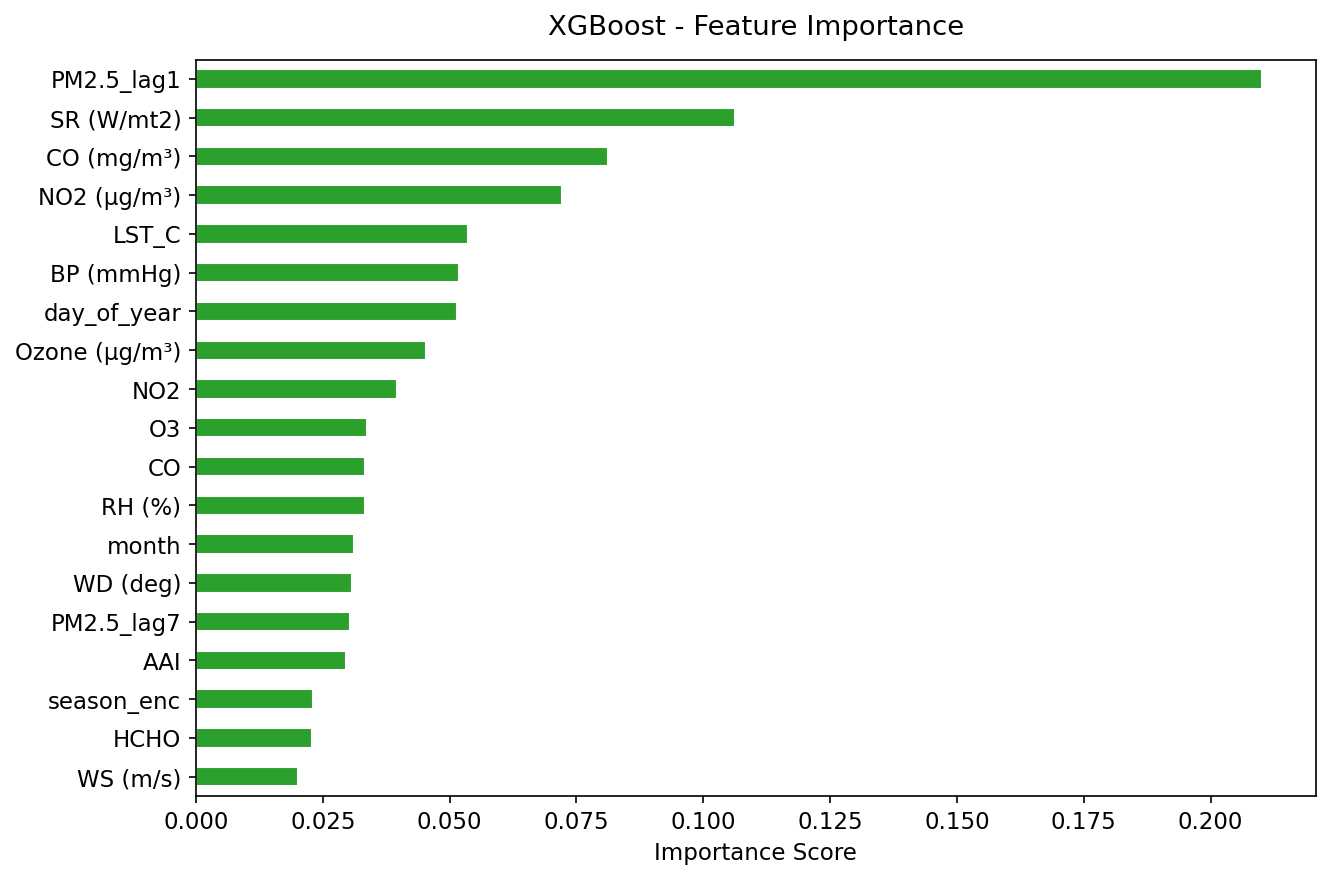

PM2.5_lag1       0.210178
SR (W/mt2)       0.106227
CO (mg/m³)       0.081318
NO2 (µg/m³)      0.072097
LST_C            0.053562
BP (mmHg)        0.051786
day_of_year      0.051519
Ozone (µg/m³)    0.045295
NO2              0.039723
O3               0.033637
CO               0.033389
RH (%)           0.033344
month            0.031094
WD (deg)         0.030812
PM2.5_lag7       0.030426
AAI              0.029484
season_enc       0.023062
HCHO             0.022971
WS (m/s)         0.020077
dtype: float32

In [8]:
assert len(xgb_model.feature_importances_) == len(FULL_USED), \
    f'Mismatch: {len(xgb_model.feature_importances_)} importances vs {len(FULL_USED)} names'

fi_xgb = pd.Series(xgb_model.feature_importances_, index=FULL_USED).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
fi_xgb.plot.barh(ax=ax, color='#2ca02c', edgecolor='white')
ax.invert_yaxis()
ax.set_title('XGBoost - Feature Importance', pad=12)
ax.set_xlabel('Importance Score')
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'feature_importance_xgb.png'))
plt.show()
fi_xgb

## 9. Actual vs Predicted — XGBoost

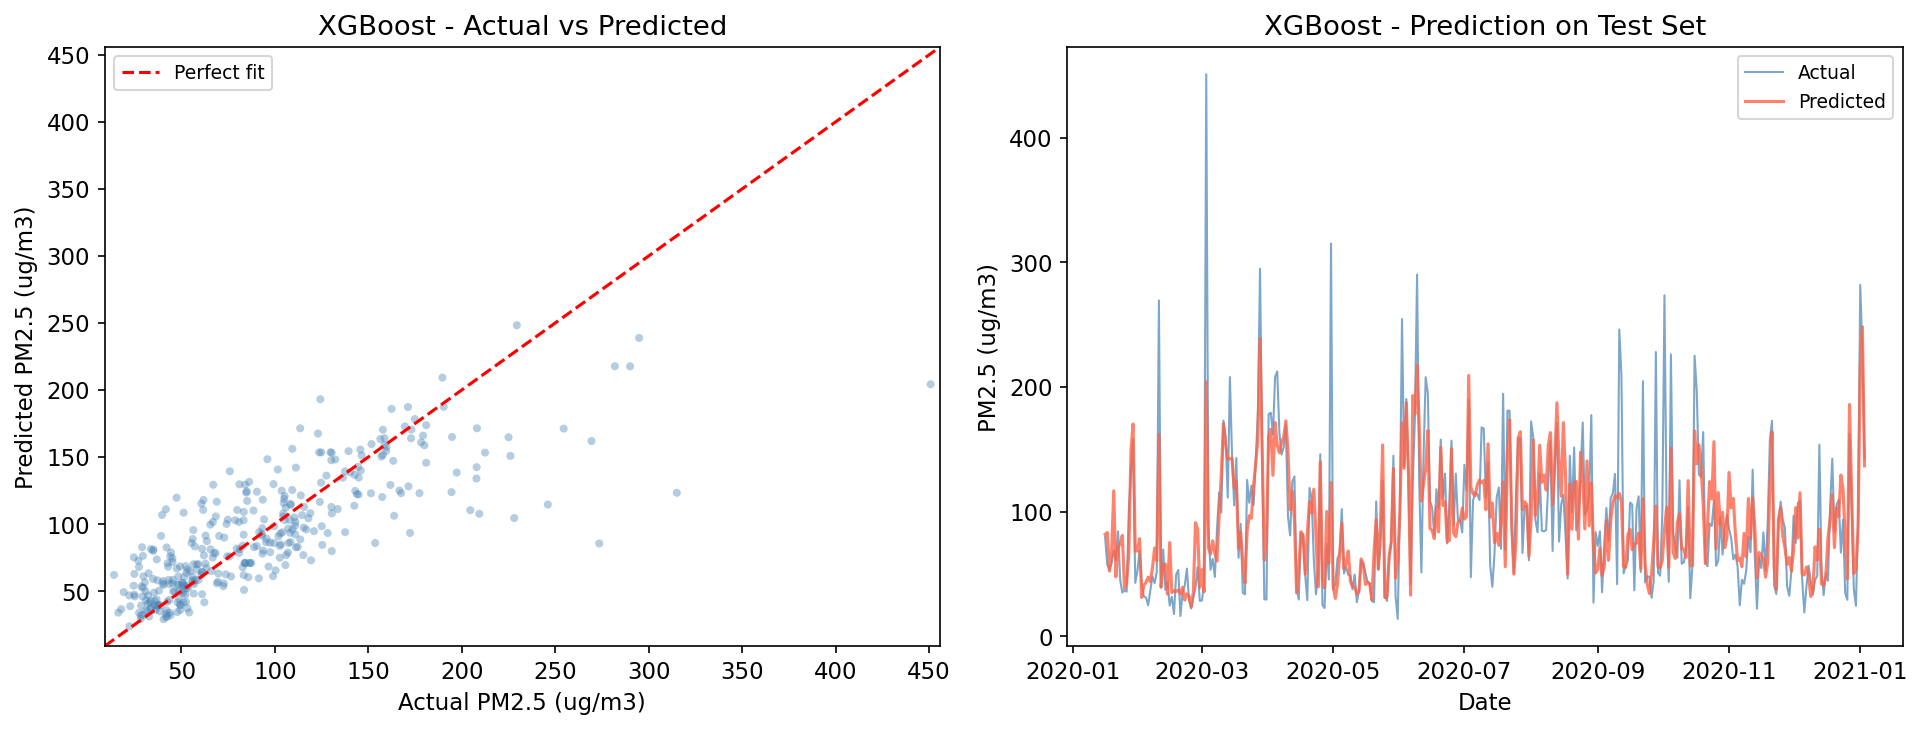

In [9]:
best_pred  = predictions['XGBoost']
test_dates = df['date'].iloc[split_idx : split_idx + len(y_test)].values

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(y_test, best_pred, alpha=0.4, s=15, color='steelblue', edgecolors='none')
lim = [min(y_test.min(), best_pred.min())-5, max(y_test.max(), best_pred.max())+5]
ax.plot(lim, lim, 'r--', lw=1.5, label='Perfect fit')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Actual PM2.5 (ug/m3)')
ax.set_ylabel('Predicted PM2.5 (ug/m3)')
ax.set_title('XGBoost - Actual vs Predicted')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(test_dates, y_test,    color='steelblue', lw=1,   alpha=0.7, label='Actual')
ax.plot(test_dates, best_pred, color='tomato',    lw=1.5, alpha=0.8, label='Predicted')
ax.set_xlabel('Date')
ax.set_ylabel('PM2.5 (ug/m3)')
ax.set_title('XGBoost - Prediction on Test Set')
ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(os.path.join(OUT, 'xgb_actual_vs_predicted.png'))
plt.show()

## 10. Residual Analysis

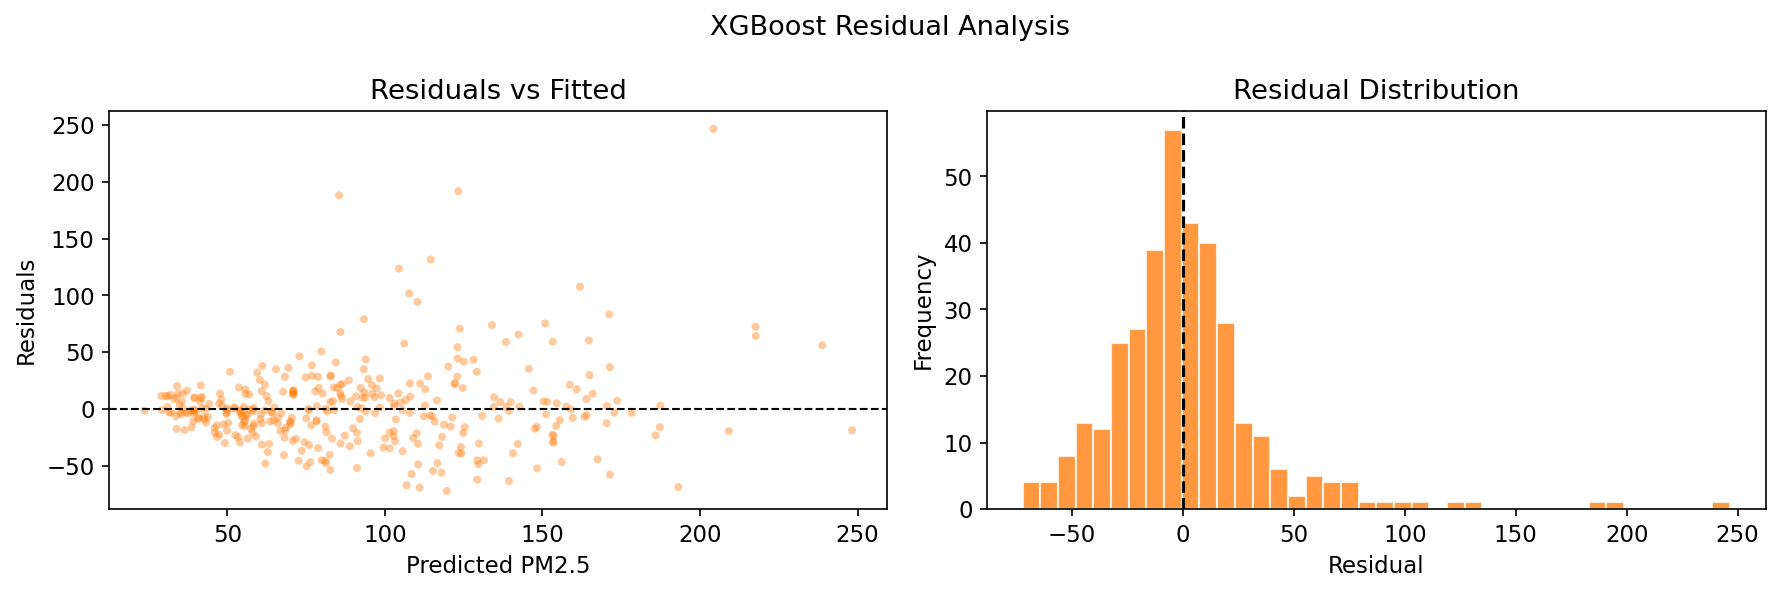

In [10]:
residuals = y_test - best_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(best_pred, residuals, alpha=0.4, s=15, color='#ff7f0e', edgecolors='none')
axes[0].axhline(0, color='black', lw=1, ls='--')
axes[0].set_xlabel('Predicted PM2.5')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

axes[1].hist(residuals, bins=40, color='#ff7f0e', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', lw=1.5, ls='--')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

plt.suptitle('XGBoost Residual Analysis', fontsize=13)
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'xgb_residuals.png'))
plt.show()